In [1]:
from google.colab import drive

drive.mount("/content/drive")
%cd /content/drive/MyDrive/Deep Learning Project/DLE-Flair-Segmentation

ValueError: mount failed

In [2]:
pip install -r requirements.txt

In [3]:
from pathlib import Path
import os
import sys

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repo root: {REPO_ROOT}")

Repo root: /content/drive/MyDrive/Deep Learning Project/DLE-Flair-Segmentation


In [7]:
import torch
import matplotlib.pyplot as plt

from src.data import build_dataloaders, load_class_map
from src.evaluate import evaluate_class_iou
from src.models import build_model, freeze_backbone
from src.train import (
    _load_env_file,
    build_loss,
    build_optimizer,
    build_scheduler,
    finish_wandb_run,
    sync_class_config,
    train_from_config,
    train_one_epoch,
    validate_one_epoch,
)
from src.utils import get_device, load_config
from src.visualize import plot_class_iou, plot_overlay_grid, plot_prediction_comparison_grid

device = get_device()
print(f"Using device: {device}")

Using device: cpu


In [13]:
config_path = REPO_ROOT / "configs" / "resnet34_unet.yaml"
config = sync_class_config(load_config(config_path))

config

{'experiment': {'name': 'resnet34_unet', 'seed': 42, 'output_dir': 'outputs'},
 'data': {'train_csv': 'data/processed/splits/train.csv',
  'val_csv': 'data/processed/splits/val.csv',
  'test_csv': 'data/processed/splits/test.csv',
  'class_map': 'data/processed/class_map.json',
  'train_stats': 'data/processed/train_stats.json',
  'image_size': 512,
  'batch_size': 8,
  'num_workers': 0,
  'channels': [1, 2, 3, 4, 5],
  'norm_type': 'scaling',
  'norm_means': [],
  'norm_stds': [],
  'ignore_index': 255,
  'augment': {'enabled': True,
   'horizontal_flip': True,
   'vertical_flip': True,
   'random_rotate_90': True},
  'num_classes': 6},
 'model': {'name': 'resnet34_unet',
  'encoder': 'resnet34',
  'pretrained': True,
  'in_channels': 6,
  'num_classes': 6},
 'training': {'max_epochs': 100,
  'min_epochs': 10,
  'warmup_frozen_epochs': 3,
  'early_stopping': {'enabled': True,
   'monitor': 'val_loss',
   'mode': 'min',
   'patience': 20,
   'min_delta': 0.0001},
  'optimizer': {'name'

In [14]:
train_loader, val_loader, test_loader = build_dataloaders(config["data"])
len(train_loader), len(val_loader), len(test_loader)

(25, 4, 4)

In [15]:
# sanity check dataloader output
def unpack_batch(batch):
    if isinstance(batch, dict):
        return batch["image"], batch["mask"]
    return batch

# get a single batch from the training dataloader and print shapes, dtypes, and value ranges
batch = next(iter(train_loader))
images, masks = unpack_batch(batch)

print("images", images.shape, images.dtype, images.min().item(), images.max().item())
print("masks ", masks.shape, masks.dtype, torch.unique(masks)[:20])

images torch.Size([8, 5, 512, 512]) torch.float32 0.0 1.0
masks  torch.Size([8, 512, 512]) torch.int64 tensor([0, 1, 2, 3, 4, 5])


In [16]:
# load class map and get class names and ignore index for visualization
class_map = load_class_map(REPO_ROOT / config["data"]["class_map"])
class_names = class_map["class_names"]
ignore_index = config["data"].get("ignore_index", class_map.get("ignore_index", 255))

# visualize a few samples from the validation set with their ground truth masks
num_viz_items = 5
viz_generator = torch.Generator().manual_seed(config["experiment"]["seed"])
viz_indices = torch.randperm(len(val_loader.dataset), generator=viz_generator)[:num_viz_items].tolist()
viz_samples = [val_loader.dataset[index] for index in viz_indices]
viz_images = torch.stack([sample["image"] for sample in viz_samples])
viz_masks = torch.stack([sample["mask"] for sample in viz_samples])

print(f"Visualization indices: {viz_indices}")
gt_overlay_fig = plot_overlay_grid(
    viz_images,
    viz_masks,
    max_items=num_viz_items,
    title="Ground truth",
    class_names=class_names,
    ignore_index=ignore_index,
)
gt_overlay_fig

Output hidden; open in https://colab.research.google.com to view.

In [21]:
import torch.nn.functional as F
import numpy as np
from tqdm.auto import tqdm

# Adjust config to match checkpoint's expected input channels and output classes
# The checkpoint's encoder.conv1.weight has shape [64, 5, 7, 7] (5 input channels)
config["model"]["in_channels"] = 5
# The checkpoint's segmentation_head.0.weight and bias imply 5 output classes
config["model"]["num_classes"] = 5

# Build the model architecture with the adjusted configuration
model = build_model(config["model"])

# Load the checkpoint (which is a dictionary)
checkpoint = torch.load(REPO_ROOT / "outputs" / config["experiment"]["name"] / "last.pt", map_location=device)

# Load the model's state dictionary from the checkpoint
model.load_state_dict(checkpoint["model_state_dict"])

# Move the model to the device and set to evaluation mode
model.to(device)
model.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(5, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [33]:
def collect_calibration_scores(model, val_loader):
    scores = []

    with torch.no_grad():
        for batch in tqdm(val_loader):
            images, masks = batch["image"], batch["mask"] # Unpack the batch dictionary
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)  # (B, C, H, W)
            probs = F.softmax(logits, dim=1)

            # Gather probability of true class
            B, C, H, W = probs.shape  # C will be 5 here
            probs = probs.permute(0, 2, 3, 1).reshape(-1, C)
            masks = masks.view(-1)

            # Filter masks to only include valid class indices for the current model (0 to C-1)
            valid_indices = (masks >= 0) & (masks < C)
            filtered_masks = masks[valid_indices]
            filtered_probs = probs[valid_indices]

            if len(filtered_masks) > 0:
                p_true = filtered_probs[torch.arange(len(filtered_masks)), filtered_masks]
                score = 1.0 - p_true
                scores.append(score.cpu().numpy())

    scores = np.concatenate(scores) if scores else np.array([])
    return scores

In [51]:
def compute_qhat(scores, alpha=0.1):
    n = len(scores)
    qhat = np.quantile(scores, np.ceil((n + 1) * (1 - alpha)) / n)
    return qhat


alpha = 0.2
scores = collect_calibration_scores(model, val_loader)
q_hat = compute_qhat(scores, alpha)

print(f"q_hat: {q_hat:.4f}")

  0%|          | 0/4 [00:00<?, ?it/s]

q_hat: 0.9700


In [52]:
def evaluate_conformal(model, test_loader, q_hat):
    total_pixels = 0
    covered_pixels = 0
    set_sizes = []

    all_set_size_maps = []  # for visualization later

    with torch.no_grad():
        for batch in tqdm(test_loader):
            images, masks = batch["image"], batch["mask"] # Unpack the batch dictionary
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            probs = F.softmax(logits, dim=1)

            # Conformal rule: include class if p_c >= 1 - q_hat
            threshold = 1.0 - q_hat
            pred_sets = probs >= threshold  # (B, C, H, W)

            # Check coverage
            C = probs.shape[1] # Number of classes the model predicts (e.g., 5)

            # Create a boolean mask for pixels whose ground truth class is within the model's prediction range
            is_valid_class_gt = (masks >= 0) & (masks < C) # (B, H, W)

            # Temporarily set invalid ground truth class values to 0 for F.one_hot (it will be masked out later)
            temp_masks_for_one_hot = masks.clone()
            temp_masks_for_one_hot[~is_valid_class_gt] = 0

            # Create one-hot encoding for all pixels using the adjusted masks
            true_class_mask_all = F.one_hot(temp_masks_for_one_hot, num_classes=C).permute(0, 3, 1, 2).bool()

            # Apply the validity mask to zero out channels for invalid ground truth pixels
            true_class_mask = true_class_mask_all & is_valid_class_gt.unsqueeze(1) # (B, C, H, W)

            covered = (pred_sets & true_class_mask).any(dim=1)

            covered_pixels += covered.sum().item()
            total_pixels += covered.numel()

            # Set size
            set_size = pred_sets.sum(dim=1)  # (B, H, W)
            set_sizes.append(set_size.cpu().numpy())

            all_set_size_maps.append(set_size.cpu())

    coverage = covered_pixels / total_pixels
    avg_set_size = np.mean(np.concatenate(set_sizes))

    return coverage, avg_set_size, all_set_size_maps

In [53]:
coverage, avg_set_size, set_size_maps = evaluate_conformal(
    model, test_loader, q_hat
)

print(f"Target coverage: {1 - alpha}")
print(f"Empirical coverage: {coverage:.4f}")
print(f"Average set size: {avg_set_size:.4f}")

  0%|          | 0/4 [00:00<?, ?it/s]

Target coverage: 0.8
Empirical coverage: 0.7366
Average set size: 4.0370


In [54]:
import matplotlib.pyplot as plt

def visualize_set_size(image, set_size):
    image = image.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(image[:, :, :3])  # show RGB only
    plt.title("Image")

    plt.subplot(1,2,2)
    plt.imshow(set_size, cmap="viridis")
    plt.colorbar()
    plt.title("Conformal Set Size")

    plt.show()

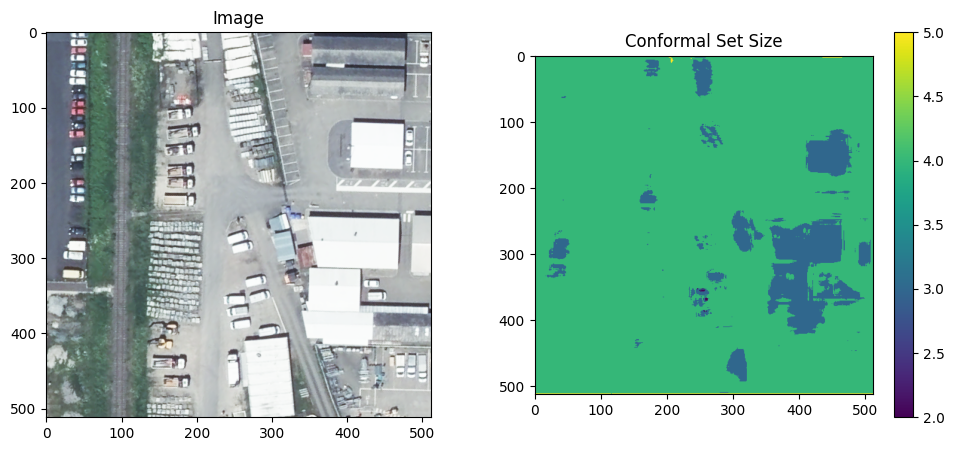

In [55]:
batch = next(iter(test_loader))
images = batch['image']

# Take first sample
image = images[5]
set_size_map = set_size_maps[0][5]

visualize_set_size(image, set_size_map)